In [1]:
import pandas as pd

train_df = pd.read_csv(
    "../data/processed/train_transactions.csv",
    parse_dates=["InvoiceDate"]
)

train_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [2]:
train_df = train_df.dropna(subset=["CustomerID"]) 

Feature scaling was not applied because the models used in this project
(RandomForestClassifier and RandomForestRegressor) are tree-based models,
which are not sensitive to the scale of input features.

In [3]:
snapshot_date = train_df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-09-10 16:36:00')

In [4]:
train_df["Revenue"] = train_df["Quantity"] * train_df["UnitPrice"]

In this section, transaction-level data is aggregated into customer-level behavioral features that will be used for churn prediction and revenue forecasting.

In [5]:
def build_customer_features(transactions, snapshot_date):
    features = transactions.groupby("CustomerID").agg(
        recency_days=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        frequency_orders=("InvoiceNo", "nunique"),
        monetary_total=("Revenue", "sum"),
        total_items=("Quantity", "sum"),
        unique_products=("StockCode", "nunique")
    )

    features["avg_order_value"] = (
        features["monetary_total"] / features["frequency_orders"]
    )

    return features

In [6]:
customer_features = build_customer_features(train_df, snapshot_date)
customer_features.head()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value
CustomerID,,,,,,
12346.0,235,2,0.00,0,1,0.000000
12347.0,39,5,2790.86,1590,82,558.172000
12348.0,158,3,1487.24,2124,22,495.746667
12350.0,220,1,334.40,197,17,334.400000
12352.0,172,8,601.18,188,26,75.147500


In [7]:
customer_features.shape

(3412, 6)

In [8]:
customer_features.isna().sum()

recency_days        0
frequency_orders    0
monetary_total      0
total_items         0
unique_products     0
avg_order_value     0
dtype: int64

In [9]:
customer_features.describe()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value
count,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000
mean,94.374853,4.221571,1504.247785,897.360199,49.525791,305.371662
std,80.729272,7.091199,5719.389332,3539.167616,67.623830,360.309138
min,1.000000,1.000000,-4287.630000,-1363.000000,1.000000,-4287.630000
25%,24.750000,1.000000,248.287500,125.000000,13.000000,143.503125
50%,73.000000,2.000000,540.775000,300.500000,29.000000,228.011417
75%,151.000000,5.000000,1329.410000,760.000000,62.000000,353.262500
max,283.000000,139.000000,177585.620000,127548.000000,1240.000000,5629.751667


The engineered customer-level features capture purchasing behavior,
including recency, order frequency, spending, and product diversity.
These features will be used as inputs for churn prediction and
revenue forecasting models.

In production machine learning systems, preprocessing steps are typically organized
into pipelines to ensure consistent transformations between training and inference.

In this project, feature engineering and preprocessing logic are implemented inside
the project’s source modules (src/feature_builder.py) rather than inside a single
Scikit-Learn pipeline, allowing better modularity and production-ready deployment.

In [10]:
future_df = pd.read_csv(
    "../data/processed/future_transactions.csv",
    parse_dates=["InvoiceDate"]
)

In [11]:
future_df = future_df.dropna(subset=["CustomerID"])

In [12]:
future_df["Revenue"] = future_df["Quantity"] * future_df["UnitPrice"]

In [13]:
future_labels = future_df.groupby("CustomerID").agg(
    future_revenue=("Revenue", "sum"),
    future_orders=("InvoiceNo", "nunique")
)

In [14]:
model_dataset = customer_features.merge(
    future_labels,
    on="CustomerID",
    how="left"
)

In [15]:
model_dataset["future_revenue"] = model_dataset["future_revenue"].fillna(0)
model_dataset["future_orders"] = model_dataset["future_orders"].fillna(0)

In [16]:
model_dataset["churn_label"] = (model_dataset["future_orders"] == 0).astype(int)

In [17]:
model_dataset.head()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,future_revenue,future_orders,churn_label
CustomerID,,,,,,,,,
12346.0,235,2,0.00,0,1,0.000000,0.00,0.0,1
12347.0,39,5,2790.86,1590,82,558.172000,1519.14,2.0,0
12348.0,158,3,1487.24,2124,22,495.746667,310.00,1.0,0
12350.0,220,1,334.40,197,17,334.400000,0.00,0.0,1
12352.0,172,8,601.18,188,26,75.147500,944.23,3.0,0


In [18]:
model_dataset.describe()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,future_revenue,future_orders,churn_label
count,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000
mean,94.374853,4.221571,1504.247785,897.360199,49.525791,305.371662,759.890147,1.762016,0.426143
std,80.729272,7.091199,5719.389332,3539.167616,67.623830,360.309138,3937.383722,3.751234,0.494588
min,1.000000,1.000000,-4287.630000,-1363.000000,1.000000,-4287.630000,-468.320000,0.000000,0.000000
25%,24.750000,1.000000,248.287500,125.000000,13.000000,143.503125,0.000000,0.000000,0.000000
50%,73.000000,2.000000,540.775000,300.500000,29.000000,228.011417,164.230000,1.000000,0.000000
75%,151.000000,5.000000,1329.410000,760.000000,62.000000,353.262500,671.932500,2.000000,1.000000
max,283.000000,139.000000,177585.620000,127548.000000,1240.000000,5629.751667,124206.550000,110.000000,1.000000


In [19]:
model_dataset.isna().sum()

recency_days        0
frequency_orders    0
monetary_total      0
total_items         0
unique_products     0
avg_order_value     0
future_revenue      0
future_orders       0
churn_label         0
dtype: int64

In [20]:
churn_dataset = model_dataset.drop(columns=["future_revenue", "future_orders"])
revenue_dataset = model_dataset.drop(columns=["churn_label", "future_orders"])

In [21]:
churn_dataset.to_csv(
    "../data/processed/churn_dataset.csv",
    index=False
)

revenue_dataset.to_csv(
    "../data/processed/revenue_dataset.csv",
    index=False
)

In [22]:
model_dataset.shape

(3412, 9)

In [23]:
model_dataset["churn_label"].value_counts()

churn_label
0    1958
1    1454
Name: count, dtype: int64

In [28]:
churn_dataset.columns

Index(['recency_days', 'frequency_orders', 'monetary_total', 'total_items',
       'unique_products', 'avg_order_value', 'churn_label'],
      dtype='object')

In [27]:
churn_dataset.shape

(3412, 7)

In [31]:
churn_dataset.head()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,churn_label
CustomerID,,,,,,,
12346.0,235,2,0.00,0,1,0.000000,1
12347.0,39,5,2790.86,1590,82,558.172000,0
12348.0,158,3,1487.24,2124,22,495.746667,0
12350.0,220,1,334.40,197,17,334.400000,1
12352.0,172,8,601.18,188,26,75.147500,0


In [29]:
revenue_dataset.columns

Index(['recency_days', 'frequency_orders', 'monetary_total', 'total_items',
       'unique_products', 'avg_order_value', 'future_revenue'],
      dtype='object')

In [30]:
revenue_dataset.shape

(3412, 7)

In [32]:
revenue_dataset.head()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,future_revenue
CustomerID,,,,,,,
12346.0,235,2,0.00,0,1,0.000000,0.00
12347.0,39,5,2790.86,1590,82,558.172000,1519.14
12348.0,158,3,1487.24,2124,22,495.746667,310.00
12350.0,220,1,334.40,197,17,334.400000,0.00
12352.0,172,8,601.18,188,26,75.147500,944.23


In [24]:
corr_matrix = model_dataset.corr(numeric_only=True)
corr_matrix

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,future_revenue,future_orders,churn_label
recency_days,1.000000,-0.319979,-0.177290,-0.175293,-0.313427,-0.108555,-0.131604,-0.259303,0.317416
frequency_orders,-0.319979,1.000000,0.547888,0.529178,0.697268,0.084212,0.430068,0.808682,-0.254128
monetary_total,-0.177290,0.547888,1.000000,0.928120,0.438338,0.497388,0.833996,0.523086,-0.139953
total_items,-0.175293,0.529178,0.928120,1.000000,0.446872,0.439893,0.691973,0.471443,-0.133775
unique_products,-0.313427,0.697268,0.438338,0.446872,1.000000,0.226289,0.315859,0.628991,-0.267202
avg_order_value,-0.108555,0.084212,0.497388,0.439893,0.226289,1.000000,0.375217,0.123057,-0.068575
future_revenue,-0.131604,0.430068,0.833996,0.691973,0.315859,0.375217,1.000000,0.578125,-0.166335
future_orders,-0.259303,0.808682,0.523086,0.471443,0.628991,0.123057,0.578125,1.000000,-0.404832
churn_label,0.317416,-0.254128,-0.139953,-0.133775,-0.267202,-0.068575,-0.166335,-0.404832,1.000000


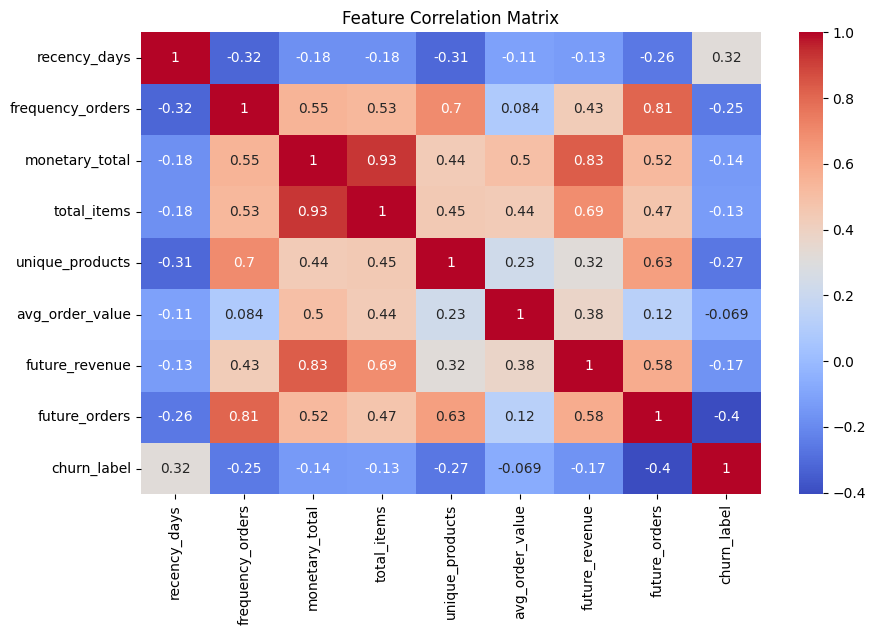

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()